# IndiaTaxBench — env-connected training (Qwen2.5 + OpenEnv Space)

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Prateedk/IndiaTaxBench-OpenEnv/blob/main/notebooks/train_qwen_india_tax.ipynb)

> **Colab tip:** the first code cell auto-clones this repo and installs `[notebook]` extras. Set Colab **Secrets** for `HF_TOKEN` (required to download Qwen weights), and optionally `ENV_URL`, `OPENAI_API_KEY`, `MODEL_NAME`. **Runtime → Change runtime type → GPU** (T4 is enough for 1.5B; 0.5B runs on small GPUs; 3B+ for more headroom).

This notebook **downloads the base model locally**, collects **rollouts against your OpenEnv Hugging Face Space** (`ENV_URL`: `reset` / `step` → observations and **rewards**), builds **SFT-style** data, and runs **TRL** training.

**Default training story (advisor):** set `TRAIN_MODE=advisor_best_of_n` (config cell). The Space runs an **advisor** episode: `POST /reset` with `{"task": "...", "advisor": true}`, then `submit_tax_advice` / optional `revise_tax_advice` / `finalize_advice`. The env scores **next-year tax-saving JSON** (rubric + efficiency), not a replacement tax engine. **Legacy:** `TRAIN_MODE=legacy_oracle_sft` keeps the original four-number `submit_prediction` / `finalize` path with oracle SFT on `india_tax_rows.jsonl`.

**Roles**

1. **`ENV_URL`** — Your IndiaTaxBench **Space** (FastAPI): environment transitions only. It does **not** run your training backward pass.
2. **Hub + local GPU** — `from_pretrained(MODEL_NAME)` and LoRA updates happen **on this machine** (Colab, HF GPU session, or your laptop GPU).
3. **Optional API policy** — If `USE_API_FOR_POLICY=1` and keys are set, the notebook can call an **OpenAI-compatible** endpoint for `generate` instead of local `model.generate` (saves VRAM for debugging). Default is **local** when CUDA is available.

**`MODEL_NAME` default:** `Qwen/Qwen2.5-1.5B-Instruct` (smaller VRAM; override e.g. `Qwen/Qwen2.5-0.5B-Instruct` for tiny, or `7B` if you have budget).

**Useful env var switches** (set in a terminal before restarting the kernel):

- `TRAIN_TASK_IDS=...` — Phase B rollouts + SFT (default: **4** tasks; the config cell **sets** this every run unless `TRAIN_TASK_IDS_USE_EXTERNAL=1` so a stale 2-task shell value is not kept).
- `HELDOUT_TASK_IDS=...` — never in SFT; still **eval**uated when `EVAL_TASK_IDS` is empty (default: e.g. STCG/LTCG + metro 80C).
- `EVAL_TASK_IDS=...` — optional; Phase D **eval** (default: **all tasks** in `server.tasks`; set a subset for faster eval).
- `MAX_ROLLOUT_TASKS=2` — if `TRAIN_TASK_IDS` is empty, use only the first N tasks (smoke).
- `NUM_ITERS` / `SFT_STEPS_PER_ITER` — training length (defaults tuned for a serious run; lower for quick smoke tests).
- `USE_API_FOR_POLICY=1` — Phase B uses the OpenAI-compatible API instead of local `model.generate`.
- `USE_ORACLE_LABELS=1` (default) — Phase C uses oracle JSON from `india_tax_capture` as the SFT target. Set to `0` to self-distill from rollouts.

**HF ~$30 credits (rough guide)**

| Goal | GPU | Notes (1.5B default) |
|------|-----|----------------|
| Default | **L4** or **A10G** | bf16/fp16 + LoRA, comfortable headroom |
| Stretch | **T4** | 1.5B/3B bf16 LoRA; 0.5B if OOM; 4-bit QLoRA as fallback |
| Avoid | **A100** long jobs | High $/hr for small LoRA gains |

Stop GPU billing when idle. Router inference is only used if `USE_API_FOR_POLICY=1`.

**Static JSONL** (optional warm-start): the next cell still loads oracle-aligned rows from `india_tax_capture/data/india_tax_rows.jsonl` for offline inspection; **Phase B onward** uses **live Space rewards**.


In [1]:
# --- Colab bootstrap (no-op locally) ---
# When opened in Google Colab via the README badge, this cell clones the
# repo, installs notebook deps, and pulls secrets so the rest of the
# notebook works the same as a local checkout.

import os
import subprocess
import sys
from pathlib import Path

IS_COLAB = "google.colab" in sys.modules
REPO_OWNER = os.environ.get("INDIA_TAX_BENCH_REPO_OWNER", "Prateedk")
REPO_NAME = os.environ.get("INDIA_TAX_BENCH_REPO_NAME", "IndiaTaxBench-OpenEnv")
REPO_BRANCH = os.environ.get("INDIA_TAX_BENCH_REPO_BRANCH", "main")

if IS_COLAB:
    repo_url = f"https://github.com/{REPO_OWNER}/{REPO_NAME}.git"
    if not Path(REPO_NAME).exists():
        subprocess.run(["git", "clone", "-b", REPO_BRANCH, repo_url], check=True)
    get_ipython().run_line_magic("cd", REPO_NAME)
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-e", ".[notebook]"],
        check=True,
    )
    try:
        from google.colab import userdata  # type: ignore

        for k in ("HF_TOKEN", "OPENAI_API_KEY", "API_KEY", "ENV_URL", "MODEL_NAME"):
            try:
                v = userdata.get(k)
            except Exception:
                v = None
            if v:
                os.environ[k] = v
    except Exception as exc:
        print("Colab Secrets unavailable:", exc)
    print("Colab bootstrap done. cwd=", Path.cwd())
else:
    print("Local run detected (not Colab); skipping bootstrap.")

Local run detected (not Colab); skipping bootstrap.


In [2]:
import os

# DO NOT hard-code real tokens here. Pick one of the safe options:
#   • Local: `export HF_TOKEN=hf_xxx` in your shell before launching Jupyter.
#   • Colab: add HF_TOKEN under Tools → Secrets; the bootstrap cell above
#     copies it into os.environ for you.
#
# This cell is a no-op safety check that just confirms the token is set
# (does NOT print the value).

if "HF_TOKEN" not in os.environ:
    print("HF_TOKEN not set — set it via shell env or Colab Secret before running training cells.")
else:
    print("HF_TOKEN is set (value hidden).")

HF_TOKEN is set (value hidden).


In [3]:
import importlib.util
import os
import sys
from pathlib import Path

# Colab / local: pip if needed
# !pip install -q "uv"  # optional
# !pip install -q transformers peft accelerate bitsandbytes trl torch matplotlib datasets openai requests ipykernel
#
# Cursor / Jupyter: register this venv as a named kernel (once), then pick it under Select Notebook Kernel:
#   uv run python -m ipykernel install --user --name openenv-india-tax-bench --display-name "openenv-india-tax-bench (IndiaTaxBench)"

REPO_ROOT = Path.cwd() if "google.colab" in sys.modules else Path("..").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# --- defaults (override with environment variables) ---
os.environ.setdefault("MODEL_NAME", "Qwen/Qwen2.5-1.5B-Instruct")
os.environ.setdefault(
    "ENV_URL",
    "https://prateekdebit-india-tax-bench-openenv.hf.space",
)
os.environ.setdefault("HTTP_TIMEOUT", "120")
# 4 default training tasks. `setdefault` is NOT used: if TRAIN_TASK_IDS is already in
# the process env (e.g. old 2-task export), it would never update. We assign unless you
# set TRAIN_TASK_IDS_USE_EXTERNAL=1 to keep only the shell/Colab value.
_DEFAULT_TRAIN_TASK_IDS = (
    "salary_non_metro_hra_fy2425,salary_capital_gains_fy2425,"
    "senior_80c_80tta_deductions_fy2425,salary_business_mixed_fy2425"
)
if os.environ.get("TRAIN_TASK_IDS_USE_EXTERNAL", "0").strip().lower() in ("1", "true", "yes"):
    os.environ.setdefault("TRAIN_TASK_IDS", _DEFAULT_TRAIN_TASK_IDS)
else:
    os.environ["TRAIN_TASK_IDS"] = _DEFAULT_TRAIN_TASK_IDS
os.environ.setdefault(
    "HELDOUT_TASK_IDS",
    "stcgt_ltcg_weighted_fy2425,salary_metro_80c_fy2425",
)  # never in SFT; eval still includes all tasks by default
os.environ.setdefault("EVAL_TASK_IDS", "")  # empty: eval on **all** catalog tasks; or comma list for a subset
os.environ.setdefault("MAX_ROLLOUT_TASKS", "")  # used only when TRAIN_TASK_IDS is empty
os.environ.setdefault("USE_API_FOR_POLICY", "0")  # "1" to use OpenAI-compatible API for policy
os.environ.setdefault("API_BASE_URL", "https://router.huggingface.co/v1")
os.environ.setdefault("USE_ORACLE_LABELS", "1")  # "1" = oracle JSON targets (better demo)
os.environ.setdefault("NUM_ITERS", "4")  # iterative SFT cycles (plot)
os.environ.setdefault("SFT_STEPS_PER_ITER", "16")  # TRL steps per iter (4*16=64 with defaults)
os.environ.setdefault("TRAIN_MODE", "advisor_best_of_n")  # legacy_oracle_sft | advisor_best_of_n | advisor_dpo
os.environ.setdefault("SAMPLES_PER_TASK", "2")  # best-of-N rollouts per training task / iter

MODEL_NAME = os.environ["MODEL_NAME"]
ENV_URL = os.environ["ENV_URL"].rstrip("/")
HTTP_TIMEOUT = float(os.environ["HTTP_TIMEOUT"])
_MAXR = os.environ.get("MAX_ROLLOUT_TASKS", "").strip()
MAX_ROLLOUT_TASKS = int(_MAXR) if _MAXR.isdigit() else None
USE_API_FOR_POLICY = os.environ.get("USE_API_FOR_POLICY", "0").strip().lower() in ("1", "true", "yes")
API_BASE_URL = os.environ["API_BASE_URL"]
TRAIN_MODE = os.environ.get("TRAIN_MODE", "advisor_best_of_n").strip()
SAMPLES_PER_TASK = int(os.environ.get("SAMPLES_PER_TASK", "2") or "2")
IS_ADVISOR = TRAIN_MODE.startswith("advisor_")
IS_LEGACY = TRAIN_MODE == "legacy_oracle_sft"

JSONL = REPO_ROOT / "india_tax_capture" / "data" / "india_tax_rows.jsonl"
PLOT_DIR = REPO_ROOT / "notebooks" / "training_plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)
ROLLOUT_JSONL = PLOT_DIR / "env_rollouts.jsonl"

# Load notebook helpers (no OpenAI import inside)
_spec = importlib.util.spec_from_file_location(
    "notebook_env_helpers",
    REPO_ROOT / "scripts" / "notebook_env_helpers.py",
)
_nbh = importlib.util.module_from_spec(_spec)
assert _spec.loader
_spec.loader.exec_module(_nbh)

print("REPO_ROOT=", REPO_ROOT)
print("MODEL_NAME=", MODEL_NAME)
print("ENV_URL=", ENV_URL)
print("USE_API_FOR_POLICY=", USE_API_FOR_POLICY)
print("PLOT_DIR=", PLOT_DIR)
print("TRAIN_MODE=", TRAIN_MODE, "IS_ADVISOR=", IS_ADVISOR, "SAMPLES_PER_TASK=", SAMPLES_PER_TASK)
print("TRAIN_TASK_IDS=", os.environ.get("TRAIN_TASK_IDS", ""))


REPO_ROOT= /data/IndiaTaxBench-OpenEnv
MODEL_NAME= Qwen/Qwen2.5-1.5B-Instruct
ENV_URL= https://prateekdebit-india-tax-bench-openenv.hf.space
USE_API_FOR_POLICY= False
PLOT_DIR= /data/IndiaTaxBench-OpenEnv/notebooks/training_plots


In [4]:
import json
from pathlib import Path

def load_sft_rows(path: Path):
    rows = []
    for line in path.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if not line:
            continue
        obj = json.loads(line)
        resp = obj.get("response") or {}
        if resp.get("_error"):
            continue
        old = (resp.get("tax_liability") or {}).get("old_regime") or {}
        comp = old.get("components") or {}
        scenario = (obj.get("request") or {}).get("scenario") or {}
        labels = {
            "total": old.get("total"),
            "initial_tax": comp.get("initial_tax"),
            "surcharge": comp.get("surcharge"),
            "cess": comp.get("cess"),
        }
        # IMPORTANT: align with inference-time prompt in scripts/notebook_env_helpers.build_predict_messages
        scenario_json_text = json.dumps(scenario, ensure_ascii=False, indent=2)
        user_msg = f"Scenario JSON:\n{scenario_json_text}\n"
        assistant = json.dumps(labels, ensure_ascii=False)
        rows.append({
            "messages": [
                {"role": "system", "content": _nbh.PREDICT_PROMPT},
                {"role": "user", "content": user_msg},
                {"role": "assistant", "content": assistant},
            ]
        })
    return rows

examples = load_sft_rows(JSONL)
len(examples), examples[0]["messages"][0]["content"][:200]


(5,
 'You are an India income tax assistant. The user gives a JSON scenario for FY 2024–25 (Assessment Year style: financial_year=2025 in the JSON). Predict **old tax regime** liability with exactly these n')

## Phase A — Space smoke test

`POST /reset` and print `task_id` / `task_difficulty` from the observation.


In [5]:
import requests
from server.tasks import ALL_TASK_IDS

# IMPORTANT: re-use a single requests.Session per episode so HF Space cookies
# persist across reset/step/finalize. Without this, the Space serves
# multiple sessions and finalize never sees the submitted prediction.
env_session = requests.Session()

assert ALL_TASK_IDS, "No tasks in JSONL — cannot reset"
probe_task = ALL_TASK_IDS[0]
r = env_session.post(
    f"{ENV_URL}/reset",
    json={"task": probe_task},
    timeout=HTTP_TIMEOUT,
)
r.raise_for_status()
payload = r.json()
obs = _nbh.unwrap_observation(payload)
print("HTTP", r.status_code, "task_id=", obs.get("task_id"), "difficulty=", obs.get("task_difficulty"))
print("valid_actions (sample)=", obs.get("valid_actions"))


HTTP 200 task_id= salary_metro_80c_fy2425 difficulty= hard
valid_actions (sample)= ['finalize', 'request_context', 'submit_prediction']


## Phase B — Rollouts (local `generate` or API) + reward plot

Mirrors `inference.py` control flow: submit → optional revise → finalize. Rewards come **only** from the Space.


/data/IndiaTaxBench-OpenEnv/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 434/434 [00:00<00:00, 848.79it/s]
[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Policy: LOCAL Qwen/Qwen2.5-1.5B-Instruct
salary_metro_80c_fy2425 final_reward= 0.04 rewards= [0.01, 0.01, 0.04]
salary_non_metro_hra_fy2425 final_reward= 0.04 rewards= [0.01, 0.01, 0.04]
business_only_fy2425 final_reward= 0.04 rewards= [0.01, 0.01, 0.04]
senior_salary_deductions_fy2425 final_reward= 0.1 rewards= [0.01, 0.01, 0.1]
salary_capital_gains_fy2425 final_reward= 0.04 rewards= [0.01, 0.01, 0.04]


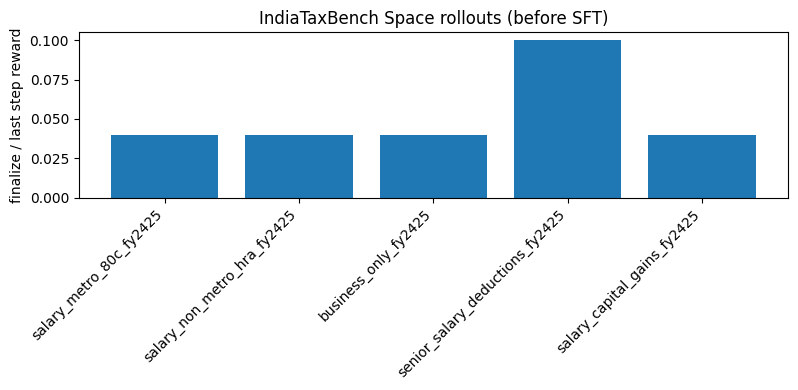

Saved /data/IndiaTaxBench-OpenEnv/notebooks/training_plots/rewards_before_sft.png


In [6]:
import json
from typing import Any, Dict, List, Optional

import matplotlib.pyplot as plt
import requests

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, get_peft_model

REVISE_THRESHOLD = 0.85
ADVISOR_REVISE_RUBRIC = 0.45  # if best rubric at submit is below this, try one revise


def new_env_session() -> requests.Session:
    """Fresh cookie jar per episode so HF Space sticks reset/step/finalize together."""
    return requests.Session()


def env_reset(task_id: str, *, sess: requests.Session, advisor: bool = False) -> dict:
    body: Dict[str, Any] = {"task": task_id}
    if advisor:
        body["advisor"] = True
    resp = sess.post(f"{ENV_URL}/reset", json=body, timeout=HTTP_TIMEOUT)
    resp.raise_for_status()
    return resp.json()


def env_step(action: Dict[str, Any], *, sess: requests.Session) -> dict:
    resp = sess.post(
        f"{ENV_URL}/step", json={"action": action}, timeout=HTTP_TIMEOUT
    )
    resp.raise_for_status()
    return resp.json()


def _local_complete(model, tokenizer, device: torch.device, messages: List[Dict[str, str]], max_new_tokens: int = 256) -> str:
    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    enc = tokenizer(text, return_tensors="pt").to(device)
    with torch.inference_mode():
        out = model.generate(
            **enc,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    gen = out[0, enc["input_ids"].shape[1] :]
    return tokenizer.decode(gen, skip_special_tokens=True).strip()


_api_client = None


def _api_complete(messages: List[Dict[str, str]], max_tokens: int = 512) -> str:
    global _api_client
    from openai import OpenAI

    if _api_client is None:
        key = (
            os.getenv("OPENAI_API_KEY")
            or os.getenv("HF_TOKEN")
            or os.getenv("API_KEY")
            or ""
        ).strip()
        if not key:
            raise ValueError("Set OPENAI_API_KEY, HF_TOKEN, or API_KEY for API policy mode")
        _api_client = OpenAI(base_url=API_BASE_URL, api_key=key)
    rsp = _api_client.chat.completions.create(
        model=MODEL_NAME,
        messages=messages,
        max_tokens=max_tokens,
        temperature=0.0,
    )
    return rsp.choices[0].message.content.strip()


def run_one_episode(
    task_id: str,
    *,
    use_api: bool,
    model=None,
    tokenizer=None,
    device: Optional[torch.device] = None,
) -> Dict[str, Any]:
    def complete(messages: List[Dict[str, str]]) -> str:
        if use_api:
            return _api_complete(messages)
        assert model and tokenizer and device is not None
        return _local_complete(model, tokenizer, device, messages)

    sess = new_env_session()
    reset_data = env_reset(task_id, sess=sess, advisor=False)
    obs = _nbh.unwrap_observation(reset_data)
    scenario = obs.get("scenario_json", "")
    rewards: List[float] = []
    raw_initial = ""
    step_obs: Dict[str, Any] = {}

    msgs = _nbh.build_predict_messages(scenario)
    raw_initial = complete(msgs)
    pred = _nbh.parse_prediction(raw_initial)
    action = {
        "action_type": "submit_prediction",
        "predicted_total": pred.get("total", 0.0),
        "predicted_initial_tax": pred.get("initial_tax", 0.0),
        "predicted_surcharge": pred.get("surcharge", 0.0),
        "predicted_cess": pred.get("cess", 0.0),
    }
    step_data = env_step(action, sess=sess)
    r, done, step_obs = _nbh.step_reward_done(step_data)
    rewards.append(r)

    if not done:
        submitted = step_obs.get("submitted_predictions", [])
        mean_score = float(submitted[-1].get("score", 0.0)) if submitted else 0.0
        if mean_score < REVISE_THRESHOLD and submitted:
            feedback = step_obs.get("feedback", "")
            prev = json.dumps(submitted[-1])
            rmsgs = _nbh.build_revise_messages(scenario, prev, feedback)
            raw_rev = complete(rmsgs)
            rp = _nbh.parse_prediction(raw_rev)
            rev_action = {
                "action_type": "revise_prediction",
                "item_index": 0,
                "predicted_total": rp.get("total", 0.0),
                "predicted_initial_tax": rp.get("initial_tax", 0.0),
                "predicted_surcharge": rp.get("surcharge", 0.0),
                "predicted_cess": rp.get("cess", 0.0),
            }
            step_data = env_step(rev_action, sess=sess)
            r, done, step_obs = _nbh.step_reward_done(step_data)
            rewards.append(r)

    if not done:
        step_data = env_step({"action_type": "finalize"}, sess=sess)
        r, done, step_obs = _nbh.step_reward_done(step_data)
        rewards.append(r)

    final_reward = rewards[-1] if rewards else 0.0
    return {
        "task_id": task_id,
        "rewards": rewards,
        "final_reward": float(final_reward),
        "scenario_json": scenario[:2000],
        "raw_initial": raw_initial[:4000],
        "last_feedback": step_obs.get("feedback", "")[:2000],
        "episode": "numeric",
    }


def run_one_advisor_episode(
    task_id: str,
    *,
    use_api: bool,
    model=None,
    tokenizer=None,
    device: Optional[torch.device] = None,
) -> Dict[str, Any]:
    def complete(messages: List[Dict[str, str]], max_new_tokens: int = 600) -> str:
        if use_api:
            return _api_complete(messages, max_tokens=max_new_tokens)
        assert model and tokenizer and device is not None
        return _local_complete(model, tokenizer, device, messages, max_new_tokens=max_new_tokens)

    sess = new_env_session()
    reset_data = env_reset(task_id, sess=sess, advisor=True)
    obs = _nbh.unwrap_observation(reset_data)
    scenario = obs.get("scenario_json", "")
    tdesc = obs.get("task_description", "")
    rewards: List[float] = []
    raw_initial = ""
    step_obs: Dict[str, Any] = {}

    msgs = _nbh.build_advisor_messages(scenario, task_id, task_description=tdesc)
    raw_initial = complete(msgs, max_new_tokens=700)
    act = {
        "action_type": "submit_tax_advice",
        "advice_text": raw_initial,
    }
    step_data = env_step(act, sess=sess)
    r, done, step_obs = _nbh.step_reward_done(step_data)
    rewards.append(r)

    if not done:
        sa = step_obs.get("submitted_advice", [])
        rub = float(sa[-1].get("rubric", 0.0)) if sa else 0.0
        if rub < ADVISOR_REVISE_RUBRIC and sa:
            feedback = step_obs.get("feedback", "")
            prev = sa[-1].get("raw", json.dumps({"note": "missing"}))[:4000]
            rmsgs = _nbh.build_revise_advisor_messages(scenario, prev, feedback)
            raw_rev = complete(rmsgs, max_new_tokens=700)
            step_data = env_step(
                {
                    "action_type": "revise_tax_advice",
                    "item_index": 0,
                    "advice_text": raw_rev,
                },
                sess=sess,
            )
            r, done, step_obs = _nbh.step_reward_done(step_data)
            rewards.append(r)
            if raw_rev:
                raw_initial = raw_rev  # for training, prefer the refined assistant text

    if not done:
        step_data = env_step({"action_type": "finalize_advice"}, sess=sess)
        r, done, step_obs = _nbh.step_reward_done(step_data)
        rewards.append(r)

    final_reward = rewards[-1] if rewards else 0.0
    return {
        "task_id": task_id,
        "rewards": rewards,
        "final_reward": float(final_reward),
        "scenario_json": scenario[:2000],
        "raw_initial": raw_initial[:8000],
        "last_feedback": step_obs.get("feedback", "")[:2000],
        "episode": "advisor",
    }


# --- choose policy backend ---
use_cuda = torch.cuda.is_available()
use_api = USE_API_FOR_POLICY or (not use_cuda)

model = tokenizer = None
device: Optional[torch.device] = None
if not use_api:
    device = torch.device("cuda")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        torch_dtype=dtype,
        device_map={"": 0},
    )
    # LoRA regularization: lower rank + higher dropout to reduce overfit on small SFT sets
    lora = LoraConfig(
        r=6,
        lora_alpha=12,
        lora_dropout=0.1,
        target_modules=["q_proj", "v_proj"],
    )
    model = get_peft_model(model, lora)
    model.eval()
    print("Policy: LOCAL", MODEL_NAME, "| TRAIN_MODE=", TRAIN_MODE)
else:
    print("Policy: API (USE_API_FOR_POLICY or no CUDA)", MODEL_NAME, "| TRAIN_MODE=", TRAIN_MODE)

# --- training rollouts: TRAIN_TASK_IDS (small/faster) else ALL with optional MAX_ROLLOUT slice ---
_tr = os.environ.get("TRAIN_TASK_IDS", "").strip()
_req_train = [s.strip() for s in _tr.split(",") if s.strip()]
if _tr:
    ids = [t.strip() for t in _tr.split(",") if t.strip() in ALL_TASK_IDS]
    for t in _req_train:
        if t not in ALL_TASK_IDS:
            print("WARNING: TRAIN_TASK_IDS not in server.tasks (ignored):", t)
    if _req_train and len(ids) < len(_req_train):
        print(
            f"WARNING: only {len(ids)}/{len(_req_train)} TRAIN_TASK_IDS are in the loaded catalog; add rows to "
            "`india_tax_capture/data/india_tax_rows.jsonl` or fix typos."
        )
else:
    ids = list(ALL_TASK_IDS)
    if MAX_ROLLOUT_TASKS is not None:
        ids = ids[: max(0, MAX_ROLLOUT_TASKS)]

# --- tasks to score in Phase D: default = **all** catalog tasks (override with EVAL_TASK_IDS) ---
_ev = os.environ.get("EVAL_TASK_IDS", "").strip()
if _ev:
    eval_ids = [t.strip() for t in _ev.split(",") if t.strip() in ALL_TASK_IDS]
    if not eval_ids:
        eval_ids = list(ALL_TASK_IDS)
        print("EVAL_TASK_IDS had no valid ids; eval on all", len(eval_ids), "tasks")
else:
    eval_ids = list(ALL_TASK_IDS)
print("Phase B: training rollouts", len(ids), "task(s):", ids)
print("Phase D: eval will use", len(eval_ids), "task(s) (all catalog):", eval_ids)

rollout_rows: List[Dict[str, Any]] = []
for tid in ids:
    if IS_ADVISOR:
        row = run_one_advisor_episode(
            tid, use_api=use_api, model=model, tokenizer=tokenizer, device=device
        )
    else:
        row = run_one_episode(
            tid, use_api=use_api, model=model, tokenizer=tokenizer, device=device
        )
    rollout_rows.append(row)
    print(tid, "mode=", row.get("episode"), "final_reward=", round(row["final_reward"], 4), "rewards=", [round(x, 4) for x in row["rewards"]])

# --- plot + save ---
plt.figure(figsize=(8, 4))
plt.bar([r["task_id"] for r in rollout_rows], [r["final_reward"] for r in rollout_rows])
plt.xticks(rotation=45, ha="right")
plt.ylabel("finalize / last step reward")
title = "IndiaTaxBench rollouts (before SFT) — " + ("advisor" if IS_ADVISOR else "numeric liability")
plt.title(title)
plt.tight_layout()
fig_before = PLOT_DIR / "rewards_before_sft.png"
plt.savefig(fig_before, dpi=150)
plt.show()
print("Saved", fig_before)


## Phase C — `env_rollouts.jsonl` for SFT

Build chat-style rows from rollout trajectories (initial model output as assistant target).


In [7]:
USE_ORACLE_LABELS = os.environ.get("USE_ORACLE_LABELS", "1").strip().lower() in ("1", "true", "yes")


def rollout_to_sft_messages(row: Dict[str, Any]) -> Dict[str, Any]:
    """Self-distill: use the model's own initial output as the SFT target (numeric)."""
    scenario = row.get("scenario_json", "")
    user_msg = f"Scenario JSON:\n{scenario}\n"
    assistant = row.get("raw_initial", "").strip()
    return {
        "messages": [
            {"role": "system", "content": _nbh.PREDICT_PROMPT},
            {"role": "user", "content": user_msg},
            {"role": "assistant", "content": assistant},
        ]
    }


def advisor_rollout_to_sft(row: Dict[str, Any]) -> Dict[str, Any]:
    """Train on the same advisor JSON the env graded in Phase B (no oracle numbers)."""
    user_msg = f"Task: {row.get('task_id', '')}\nScenario JSON:\n{row.get('scenario_json', '')}\n"
    assistant = row.get("raw_initial", "").strip()
    return {
        "messages": [
            {"role": "system", "content": _nbh.ADVISOR_SYSTEM_PROMPT},
            {"role": "user", "content": user_msg},
            {"role": "assistant", "content": assistant},
        ]
    }


HELDOUT_IDS = {x.strip() for x in os.environ.get("HELDOUT_TASK_IDS", "").split(",") if x.strip()}

if IS_ADVISOR:
    sft_from_env = [advisor_rollout_to_sft(r) for r in rollout_rows if r.get("task_id") not in HELDOUT_IDS]
    label_source = f"advisor Phase B rollouts (env-rubric); held out {sorted(HELDOUT_IDS) or '<none>'}"
elif IS_LEGACY and USE_ORACLE_LABELS:
    oracle_by_task = dict(zip(ALL_TASK_IDS, examples))
    sft_from_env = [ex for tid, ex in oracle_by_task.items() if tid not in HELDOUT_IDS]
    label_source = f"oracle (taxcalcindia JSONL); held out {sorted(HELDOUT_IDS) or '<none>'}"
else:
    sft_from_env = [rollout_to_sft_messages(r) for r in rollout_rows if r.get("task_id") not in HELDOUT_IDS]
    label_source = "self-distill numeric (model rollouts; held out)"

ROLLOUT_JSONL.write_text(
    "\n".join(json.dumps(x, ensure_ascii=False) for x in sft_from_env) + "\n",
    encoding="utf-8",
)
print(f"Phase C: wrote {len(sft_from_env)} SFT rows ({label_source}) to {ROLLOUT_JSONL}")


Phase C: wrote 4 SFT rows (oracle (taxcalcindia JSONL); held out ['salary_capital_gains_fy2425']) to /data/IndiaTaxBench-OpenEnv/notebooks/training_plots/env_rollouts.jsonl


## Phase D — TRL over N iterations (GPU)

Runs **`NUM_ITERS`** training cycles. **Eval** uses `eval_ids` from Phase B: by default **all** tasks in `server.tasks` (set `EVAL_TASK_IDS` to a subset for speed). **advisor** = `run_one_advisor_episode` (`advisor: true`); **legacy** = `run_one_episode`. For **`advisor_best_of_n`**, each iteration rebuilds SFT from the **best of `SAMPLES_PER_TASK` rollouts** per *training* task. `HELDOUT_TASK_IDS` are **never in SFT** rows; they still appear in full-corpus eval and show as **\[held-out\]** in logs.


mean final reward (before SFT, Phase B)= 0.052
Phase D: NUM_ITERS=5, SFT_STEPS_PER_ITER=28, total steps=140
Phase D: training rows=4; held out from training=['salary_capital_gains_fy2425']
== eval @ iter 0 (baseline) ==
  salary_metro_80c_fy2425: final_reward=0.04
  salary_non_metro_hra_fy2425: final_reward=0.04
  business_only_fy2425: final_reward=0.04
  senior_salary_deductions_fy2425: final_reward=0.1
  salary_capital_gains_fy2425 [held-out]: final_reward=0.04

=== Iter 1/5: training 28 TRL steps ===


Tokenizing train dataset: 100%|██████████| 4/4 [00:00<00:00, 595.57 examples/s]
[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
10,2.340913
20,1.894002


== eval @ iter 1 (+28 steps) ==
  salary_metro_80c_fy2425: final_reward=0.29
  salary_non_metro_hra_fy2425: final_reward=0.29
  business_only_fy2425: final_reward=0.04
  senior_salary_deductions_fy2425: final_reward=0.1
  salary_capital_gains_fy2425 [held-out]: final_reward=0.04

=== Iter 2/5: training 28 TRL steps ===


Tokenizing train dataset: 100%|██████████| 4/4 [00:00<00:00, 630.60 examples/s]


...

Step,Training Loss
10,0.170919
20,0.095934


== eval @ iter 4 (+28 steps) ==
  salary_metro_80c_fy2425: final_reward=0.29
  salary_non_metro_hra_fy2425: final_reward=0.29
  business_only_fy2425: final_reward=0.29
  senior_salary_deductions_fy2425: final_reward=0.99
  salary_capital_gains_fy2425 [held-out]: final_reward=0.29

=== Iter 5/5: training 28 TRL steps ===


Tokenizing train dataset: 100%|██████████| 4/4 [00:00<00:00, 656.51 examples/s]


Step,Training Loss
10,0.090362
20,0.038983


== eval @ iter 5 (+28 steps) ==
  salary_metro_80c_fy2425: final_reward=0.99
  salary_non_metro_hra_fy2425: final_reward=0.29
  business_only_fy2425: final_reward=0.99
  senior_salary_deductions_fy2425: final_reward=0.99
  salary_capital_gains_fy2425 [held-out]: final_reward=0.29

---- BEFORE SFT raw output (first task) ----
{
  "total": 267900,
  "initial_tax": 66975,
  "surcharge": 10036,
  "cess": 1300
}
---- AFTER  SFT raw output (first task) ----
{"total": 242580, "initial_tax": 233250.0, "surcharge": 0.0, "cess": 9330.0}


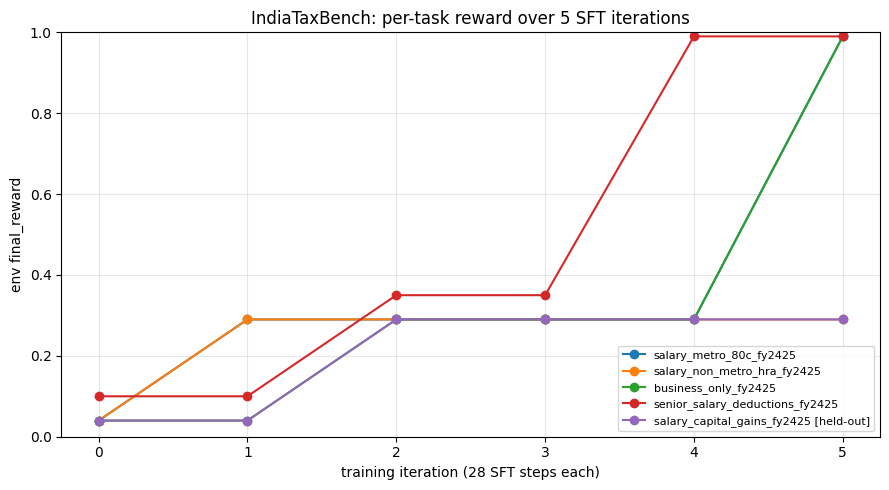

Saved /data/IndiaTaxBench-OpenEnv/notebooks/training_plots/rewards_per_task_over_iters.png


In [8]:
if "eval_ids" not in globals() or "rollout_rows" not in globals():
    raise RuntimeError("Run Phase B first (it defines ids, eval_ids, rollout_rows, and the policy).")
mean_before = sum(r["final_reward"] for r in rollout_rows) / max(1, len(rollout_rows))
print("mean final reward (before SFT, Phase B)=", round(mean_before, 4))

NUM_ITERS = int(os.environ.get("NUM_ITERS", "4"))
SFT_STEPS_PER_ITER = int(os.environ.get("SFT_STEPS_PER_ITER", "16"))
print(f"Phase D: TRAIN_MODE={TRAIN_MODE} NUM_ITERS={NUM_ITERS}, SFT_STEPS_PER_ITER={SFT_STEPS_PER_ITER}, total steps={NUM_ITERS * SFT_STEPS_PER_ITER}")
print(f"Phase D: base training rows={len(sft_from_env)}; held out from training={sorted(HELDOUT_IDS) or '<none>'}")

training_ids = [t for t in ids if t not in HELDOUT_IDS]
per_iter_rewards = {tid: [] for tid in eval_ids}
per_iter_raw_initial = {tid: [] for tid in eval_ids}


def _run_policy_episode(tid: str):
    if IS_ADVISOR:
        return run_one_advisor_episode(
            tid, use_api=use_api, model=model, tokenizer=tokenizer, device=device
        )
    return run_one_episode(
        tid, use_api=use_api, model=model, tokenizer=tokenizer, device=device
    )


def _eval_all_tasks(label: str):
    print(f"== eval @ {label} ==")
    for tid in eval_ids:
        row = _run_policy_episode(tid)
        per_iter_rewards[tid].append(row["final_reward"])
        per_iter_raw_initial[tid].append(row.get("raw_initial", "")[:400])
        held = " [held-out]" if tid in HELDOUT_IDS else ""
        print(f"  {tid}{held}: final_reward={round(row['final_reward'], 4)}")


def _build_best_of_n_dataset():
    """Refresh SFT rows from the env by keeping the best of SAMPLES_PER_TASK rollouts per training task."""
    out = []
    for tid in training_ids:
        best = None
        for _ in range(max(1, SAMPLES_PER_TASK)):
            r = run_one_advisor_episode(
                tid, use_api=use_api, model=model, tokenizer=tokenizer, device=device
            )
            if best is None or r["final_reward"] > best["final_reward"]:
                best = r
        if best is not None:
            out.append(advisor_rollout_to_sft(best))
    return out


# iter 0 = baseline (no SFT yet)
_eval_all_tasks("iter 0 (baseline)")

if model is not None and use_cuda and not use_api:
    try:
        from datasets import Dataset
        from trl import SFTConfig, SFTTrainer

        def formatting_func(example):
            return tokenizer.apply_chat_template(
                example["messages"], tokenize=False, add_generation_prompt=False
            )

        if TRAIN_MODE == "advisor_dpo":
            print(
                "Note: `advisor_dpo` reuses the same SFT+env path as `advisor_best_of_n` in this notebook. "
                "A full DPO run needs explicit chosen/rejected pairs; extend with TRL DPOTrainer as needed."
            )
        for it in range(1, NUM_ITERS + 1):
            print(f"\n=== Iter {it}/{NUM_ITERS}: training {SFT_STEPS_PER_ITER} TRL steps ===")

            if TRAIN_MODE == "advisor_best_of_n" and IS_ADVISOR:
                rows = _build_best_of_n_dataset()
                train_ds = Dataset.from_list(rows if rows else sft_from_env)
            else:
                train_ds = Dataset.from_list(sft_from_env)

            sft_kwargs = dict(
                output_dir=str(PLOT_DIR / f"sft_iter_{it}"),
                max_steps=SFT_STEPS_PER_ITER,
                per_device_train_batch_size=1,
                gradient_accumulation_steps=1,
                learning_rate=1.5e-4,
                weight_decay=0.01,
                warmup_ratio=0.1,
                lr_scheduler_type="cosine",
                bf16=torch.cuda.is_bf16_supported(),
                fp16=not torch.cuda.is_bf16_supported(),
                logging_steps=1,
                logging_first_step=True,
                report_to=[],
            )
            try:
                sft_config = SFTConfig(max_seq_length=2048, **sft_kwargs)
            except TypeError:
                sft_config = SFTConfig(**sft_kwargs)
            trainer_kwargs = dict(
                model=model,
                args=sft_config,
                train_dataset=train_ds,
                formatting_func=formatting_func,
            )
            try:
                trainer = SFTTrainer(processing_class=tokenizer, **trainer_kwargs)
            except TypeError:
                try:
                    trainer = SFTTrainer(tokenizer=tokenizer, max_seq_length=2048, **trainer_kwargs)
                except TypeError:
                    trainer = SFTTrainer(tokenizer=tokenizer, **trainer_kwargs)
            trainer.train()
            try:
                model.gradient_checkpointing_disable()
            except Exception:
                pass
            try:
                model.config.use_cache = True
            except Exception:
                pass
            model.eval()
            _eval_all_tasks(f"iter {it} (+{SFT_STEPS_PER_ITER} steps)")
    except Exception as exc:
        print("SFT iter loop skipped:", exc)
else:
    print("SFT iter loop skipped (API policy or no CUDA); only baseline eval recorded.")

print("\n---- BEFORE SFT raw output (first eval task) ----")
_ek0 = eval_ids[0] if eval_ids else None
if _ek0 and per_iter_raw_initial.get(_ek0):
    print(per_iter_raw_initial[_ek0][0] if per_iter_raw_initial[_ek0] else "(no eval recorded)")
else:
    print("(no eval recorded)")
print("---- AFTER  SFT raw output (first eval task) ----")
if _ek0 and len(per_iter_raw_initial.get(_ek0, [])) > 1:
    print(per_iter_raw_initial[_ek0][-1])
else:
    print("(no post-train eval recorded)")

# --- N-line per-task reward curve (one line per task in `ids`) ---
import matplotlib.pyplot as plt

xs = list(range(NUM_ITERS + 1))
plt.figure(figsize=(9, 5))
for tid in eval_ids:
    label = f"{tid}{' [held-out]' if tid in HELDOUT_IDS else ''}"
    rewards = per_iter_rewards[tid]
    if not rewards:
        continue
    if len(rewards) < len(xs):
        rewards = rewards + [rewards[-1]] * (len(xs) - len(rewards))
    plt.plot(xs, rewards, marker="o", label=label, ms=3)
plt.xlabel(f"training iteration ({SFT_STEPS_PER_ITER} SFT steps each when GPU SFT runs)")
plt.ylabel("env final_reward")
plt.ylim(0.0, 1.0)
mode_title = "advisor" if IS_ADVISOR else "numeric"
plt.title(f"IndiaTaxBench ({mode_title}): per-task reward over {NUM_ITERS} iterations")
plt.legend(loc="lower right", fontsize=6)
plt.grid(True, alpha=0.3)
plt.tight_layout()
fig_iter = PLOT_DIR / "rewards_per_task_over_iters.png"
plt.savefig(fig_iter, dpi=150)
plt.show()
print("Saved", fig_iter)
